In [35]:
!git clone https://github.com/mwaskom/seaborn-data.git

fatal: destination path 'seaborn-data' already exists and is not an empty directory.


In [36]:
#check the file is there
!ls seaborn-data | grep iris

iris.csv


In [37]:
#load iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('seaborn-data/iris.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [38]:
import os
os.makedirs('data', exist_ok=True)
df.to_csv('data/iris.csv', index=False)
print(df.shape)

(150, 5)


In [39]:
#Basic checks
print(df.info())
print(df.isnull().sum())
print(df['species'].value_counts())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


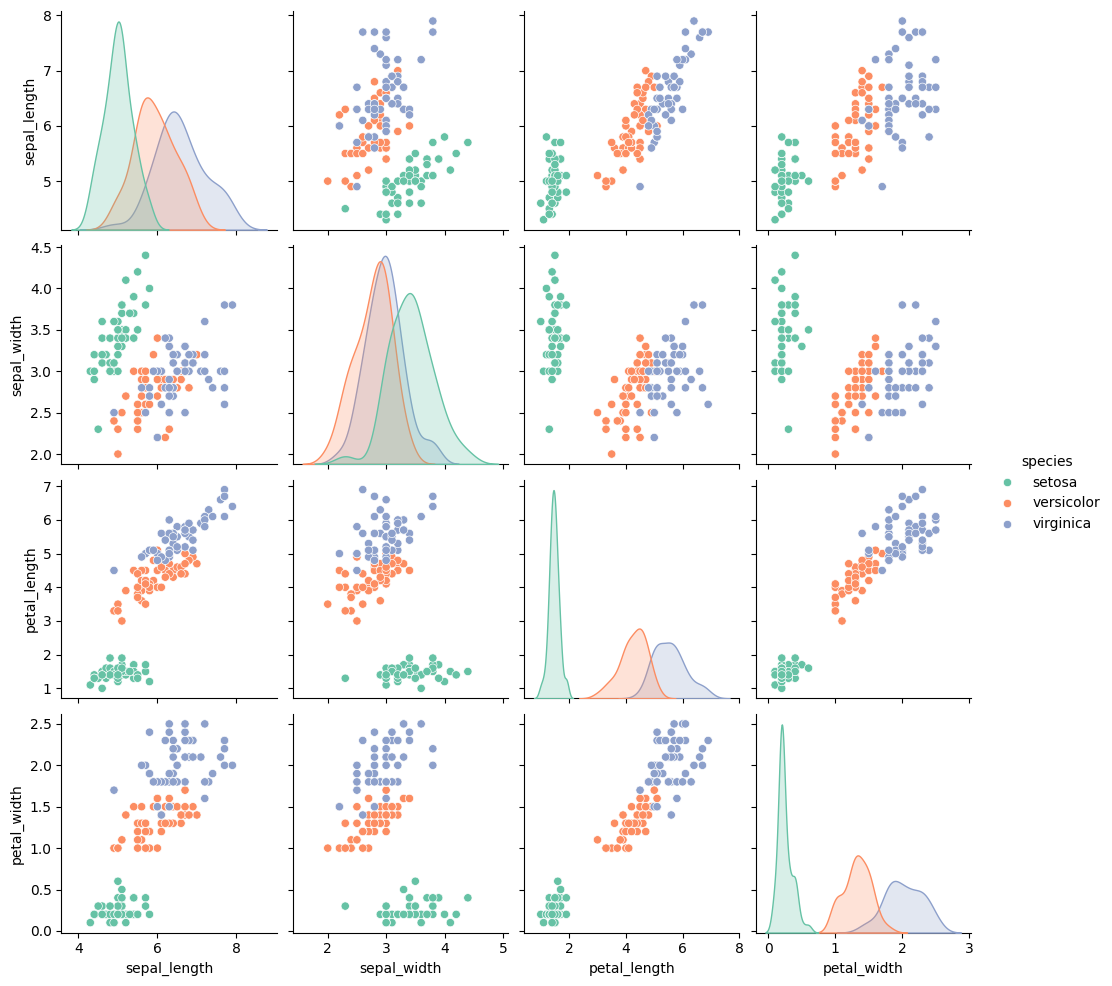

In [40]:
#feature plan visualization
sns.pairplot(df, hue='species', palette='Set2')
plt.show()


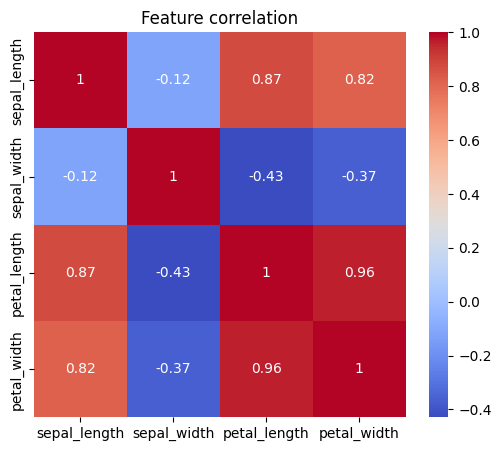

In [41]:
#correlation Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(df.drop(columns='species').corr(), annot=True, cmap='coolwarm')
plt.title('Feature correlation')
plt.show()

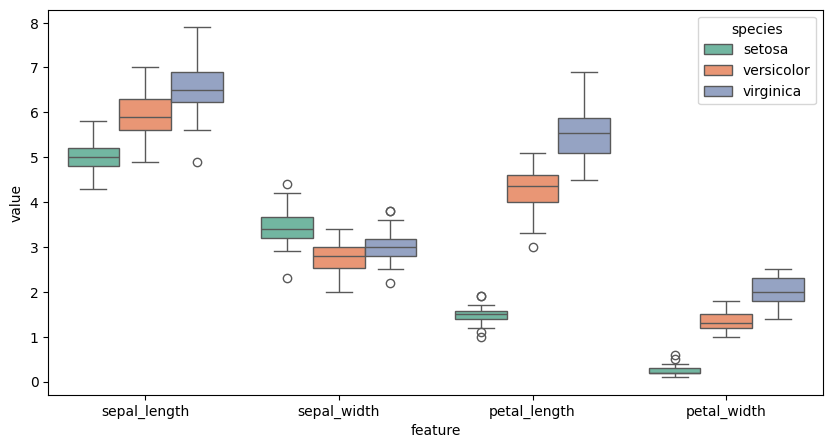

In [42]:
#Boxplot by species
df_melt = df.melt(id_vars='species', var_name='feature', value_name='value')
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_melt, x='feature', y='value', hue='species', palette='Set2')
plt.show()

## Exploratory Data Analysis (EDA) completed
EDA was performed using: dataset shape and info, missing value check, class balance, descriptive statistics, pairplot of feature pairs, correlation heatmap and boxplots by species.
Key finding: setosa is clearly separable, while versicolor and virginica overlap slightly.

In [43]:
from sklearn.model_selection import train_test_split

X = df.iloc[:, :4]   # the 4 measurement columns
y = df.iloc[:, 4]    # the species column

# Step 1: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
# Step 2: split the 30% equally into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print('Train     :', X_train.shape)
print('Validation:', X_val.shape)
print('Test      :', X_test.shape)

Train     : (105, 4)
Validation: (22, 4)
Test      : (23, 4)


In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

log_model = LogisticRegression(max_iter=200)
tree_model = DecisionTreeClassifier(random_state=42)

log_model.fit(X_train, y_train)
tree_model.fit(X_train, y_train)

log_val = accuracy_score(y_val, log_model.predict(X_val))
tree_val = accuracy_score(y_val, tree_model.predict(X_val))

print('Validation accuracy')
print('Logistic Regression:', round(log_val, 4))
print('Decision Tree      :', round(tree_val, 4))

Validation accuracy
Logistic Regression: 0.8636
Decision Tree      : 0.9545


In [45]:
#Final accuracy on the test set
log_test = accuracy_score(y_test, log_model.predict(X_test))
tree_test = accuracy_score(y_test, tree_model.predict(X_test))

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Validation Accuracy': [log_val, tree_val],
    'Test Accuracy': [log_test, tree_test]
})
results

,Model,Validation Accuracy,Test Accuracy
0,Logistic Regression,0.863636,1.000000
1,Decision Tree,0.954545,0.913043


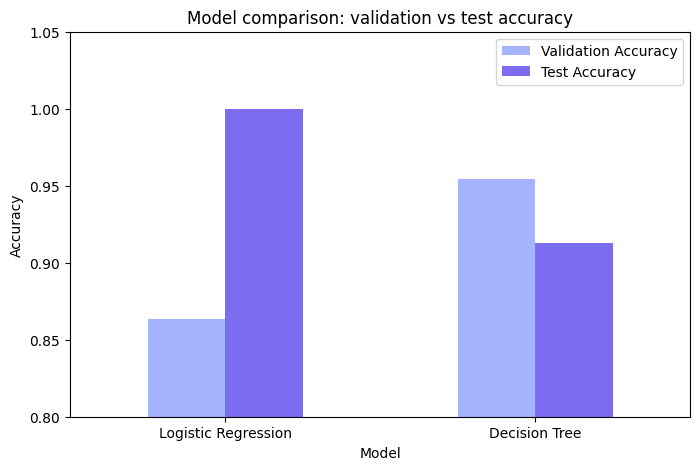

In [46]:
#Accuracy Comparison Chart
results.set_index('Model').plot(kind='bar', figsize=(8, 5), ylim=(0.8, 1.05), color=['#a5b4fc', '#7c6cf0'])
plt.title('Model comparison: validation vs test accuracy')
plt.ylabel('Accuracy')
plt.xticks(rotation=0)
plt.show()

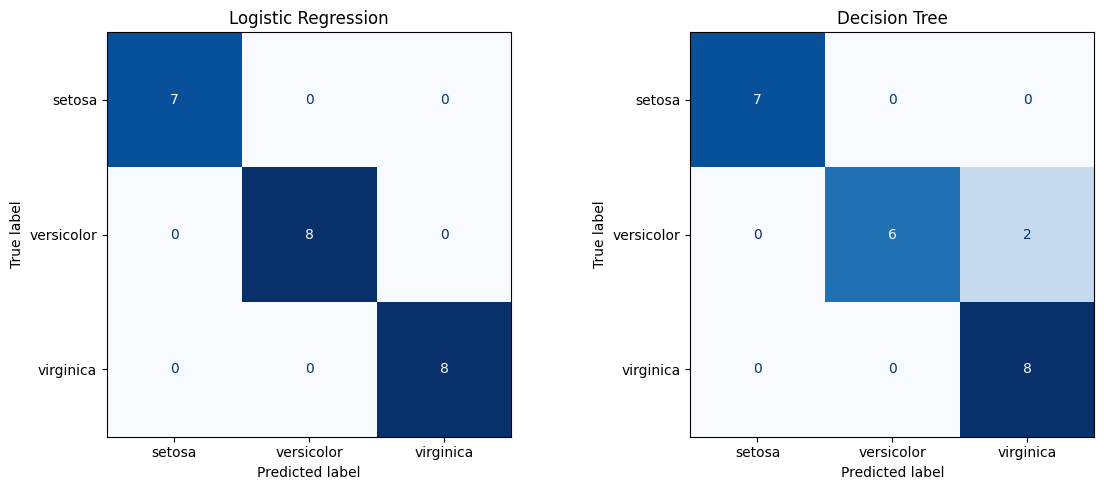

--- Logistic Regression ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         7
  versicolor       1.00      1.00      1.00         8
   virginica       1.00      1.00      1.00         8

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23

--- Decision Tree ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         7
  versicolor       1.00      0.75      0.86         8
   virginica       0.80      1.00      0.89         8

    accuracy                           0.91        23
   macro avg       0.93      0.92      0.92        23
weighted avg       0.93      0.91      0.91        23



In [47]:
#confusion matrx on test set
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_estimator(log_model, X_test, y_test, cmap='Blues', ax=ax[0], colorbar=False)
ax[0].set_title('Logistic Regression')
ConfusionMatrixDisplay.from_estimator(tree_model, X_test, y_test, cmap='Blues', ax=ax[1], colorbar=False)
ax[1].set_title('Decision Tree')
plt.tight_layout()
plt.show()

print('--- Logistic Regression ---')
print(classification_report(y_test, log_model.predict(X_test)))
print('--- Decision Tree ---')
print(classification_report(y_test, tree_model.predict(X_test)))

In [48]:
#show which flower is misclassified
pred = log_model.predict(X_test)
wrong = X_test[pred != y_test].copy()
wrong['actual'] = y_test[pred != y_test]
wrong['predicted'] = pred[pred != y_test]
wrong

,sepal_length,sepal_width,petal_length,petal_width,actual,predicted


In [49]:
#see which flower dt got wrong
tree_pred = tree_model.predict(X_test)
tree_wrong = X_test[tree_pred != y_test].copy()
tree_wrong['actual'] = y_test[tree_pred != y_test]
tree_wrong['predicted'] = tree_pred[tree_pred != y_test]
tree_wrong

,sepal_length,sepal_width,petal_length,petal_width,actual,predicted
56,6.3,3.3,4.7,1.6,versicolor,virginica
85,6.0,3.4,4.5,1.6,versicolor,virginica


In [50]:
#5-Fold cross validation
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in [('Logistic Regression', LogisticRegression(max_iter=200)),
                    ('Decision Tree', DecisionTreeClassifier(random_state=42))]:
    scores = cross_val_score(model, X, y, cv=cv)
    print(name)
    print('  fold scores:', scores.round(3))
    print('  mean accuracy:', round(scores.mean(), 4), '| std:', round(scores.std(), 4))

Logistic Regression
  fold scores: [1.    0.967 0.933 1.    0.933]
  mean accuracy: 0.9667 | std: 0.0298
Decision Tree
  fold scores: [1.    0.967 0.933 0.967 0.9  ]
  mean accuracy: 0.9533 | std: 0.034


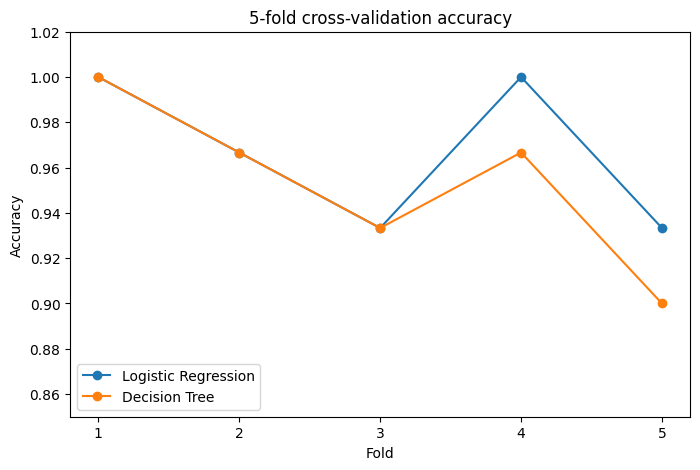

In [51]:
#chart of fold scores
cv_results = pd.DataFrame({
    'Fold': [1, 2, 3, 4, 5],
    'Logistic Regression': cross_val_score(LogisticRegression(max_iter=200), X, y, cv=cv),
    'Decision Tree': cross_val_score(DecisionTreeClassifier(random_state=42), X, y, cv=cv)
}).set_index('Fold')

cv_results.plot(marker='o', figsize=(8, 5), ylim=(0.85, 1.02))
plt.title('5-fold cross-validation accuracy')
plt.ylabel('Accuracy')
plt.xticks([1, 2, 3, 4, 5])
plt.show()

In [52]:
#save both models
import joblib

joblib.dump(log_model, 'logistic_regression_model.joblib')
joblib.dump(tree_model, 'decision_tree_model.joblib')

!ls -lh *.joblib

-rw-r--r-- 1 root root 3.1K Sep 29 04:40 decision_tree_model.joblib
-rw-r--r-- 1 root root 1.4K Sep 29 04:40 logistic_regression_model.joblib


In [53]:
from google.colab import files

files.download('logistic_regression_model.joblib')
files.download('decision_tree_model.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [54]:
#create CLI script
%%writefile predict.py
import argparse
import joblib
import pandas as pd

parser = argparse.ArgumentParser(description='Predict iris species from measurements in cm')
parser.add_argument('--sepal_length', type=float, required=True)
parser.add_argument('--sepal_width', type=float, required=True)
parser.add_argument('--petal_length', type=float, required=True)
parser.add_argument('--petal_width', type=float, required=True)
args = parser.parse_args()

model = joblib.load('logistic_regression_model.joblib')

x = pd.DataFrame(
    [[args.sepal_length, args.sepal_width, args.petal_length, args.petal_width]],
    columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
)

prediction = model.predict(x)[0]
confidence = model.predict_proba(x)[0].max()
print(f'Predicted species: {prediction} (confidence: {confidence:.1%})')

Overwriting predict.py


In [55]:
!python predict.py --sepal_length 5.1 --sepal_width 3.5 --petal_length 1.4 --petal_width 0.2
!python predict.py --sepal_length 6.7 --sepal_width 3.0 --petal_length 5.2 --petal_width 2.3

Predicted species: setosa (confidence: 97.7%)
Predicted species: virginica (confidence: 90.4%)


In [56]:
%%writefile requirements.txt
pandas
numpy
matplotlib
seaborn
scikit-learn
joblib

Overwriting requirements.txt


In [57]:
from google.colab import files

files.download('predict.py')
files.download('requirements.txt')
files.download('logistic_regression_model.joblib')
files.download('decision_tree_model.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [58]:
print('Training vs validation vs test accuracy')
for name, m in [('Logistic Regression', log_model), ('Decision Tree', tree_model)]:
    tr = accuracy_score(y_train, m.predict(X_train))
    va = accuracy_score(y_val, m.predict(X_val))
    te = accuracy_score(y_test, m.predict(X_test))
    print(f'{name:20s} train={tr:.3f}  val={va:.3f}  test={te:.3f}')

Training vs validation vs test accuracy
Logistic Regression  train=0.971  val=0.864  test=1.000
Decision Tree        train=1.000  val=0.955  test=0.913


In [59]:
examples = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2],
     [5.9, 3.0, 4.2, 1.5],
     [6.7, 3.0, 5.2, 2.3],
     [6.3, 3.3, 4.7, 1.6],
     [4.9, 3.0, 1.4, 0.2]],
    columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
)

examples['predicted_species'] = log_model.predict(examples)
examples['confidence_%'] = (log_model.predict_proba(examples.iloc[:, :4]).max(axis=1) * 100).round(1)
examples

,sepal_length,sepal_width,petal_length,petal_width,predicted_species,confidence_%
0,5.1,3.5,1.4,0.2,setosa,97.7
1,5.9,3.0,4.2,1.5,versicolor,87.0
2,6.7,3.0,5.2,2.3,virginica,90.4
3,6.3,3.3,4.7,1.6,versicolor,66.2
4,4.9,3.0,1.4,0.2,setosa,96.6


In [60]:
check = X_test.sample(8, random_state=1).copy()
check['actual'] = y_test[check.index]
check['predicted'] = log_model.predict(check.iloc[:, :4])
check['correct'] = check['actual'] == check['predicted']
check

,sepal_length,sepal_width,petal_length,petal_width,actual,predicted,correct
55,5.7,2.8,4.5,1.3,versicolor,versicolor,True
85,6.0,3.4,4.5,1.6,versicolor,versicolor,True
57,4.9,2.4,3.3,1.0,versicolor,versicolor,True
132,6.4,2.8,5.6,2.2,virginica,virginica,True
10,5.4,3.7,1.5,0.2,setosa,setosa,True
49,5.0,3.3,1.4,0.2,setosa,setosa,True
58,6.6,2.9,4.6,1.3,versicolor,versicolor,True
127,6.1,3.0,4.9,1.8,virginica,virginica,True


In [62]:
#iris flower predictor ui
import os, subprocess, joblib
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Fresh Colab? Download the project from GitHub automatically
if not os.path.exists('logistic_regression_model.joblib'):
    subprocess.run(['git', 'clone', 'https://github.com/Priyadh1/Syntecxhub_Flower_classification.git'])
    os.chdir('Syntecxhub_Flower_classification')

model = joblib.load('logistic_regression_model.joblib')
COLUMNS = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
DEFAULTS = (5.8, 3.0, 4.0, 1.2)
ORANGE = '#f97316'

# ---------- Inputs (left side) ----------
sty = {'description_width': '130px'}
lay = widgets.Layout(width='430px')
sl = widgets.FloatSlider(value=DEFAULTS[0], min=4.0, max=8.0, step=0.1, description='Sepal length (cm)', style=sty, layout=lay)
sw = widgets.FloatSlider(value=DEFAULTS[1], min=2.0, max=4.5, step=0.1, description='Sepal width (cm)', style=sty, layout=lay)
pl = widgets.FloatSlider(value=DEFAULTS[2], min=1.0, max=7.0, step=0.1, description='Petal length (cm)', style=sty, layout=lay)
pw = widgets.FloatSlider(value=DEFAULTS[3], min=0.1, max=2.6, step=0.1, description='Petal width (cm)', style=sty, layout=lay)

clear_btn = widgets.Button(description='Clear', layout=widgets.Layout(width='200px', height='38px'))
submit_btn = widgets.Button(description='Submit', button_style='warning', layout=widgets.Layout(width='200px', height='38px'))

# ---------- Output (right side) ----------
def render(result=None):
    if result is None:
        body = "<div style='color:#9ca3af;padding:40px 0;text-align:center'>Press Submit to see the prediction</div>"
    else:
        top = max(result, key=result.get)
        rows = ''
        for name, p in sorted(result.items(), key=lambda t: -t[1]):
            rows += (f"<div style='margin:10px 0'>"
                     f"<div style='display:flex;justify-content:space-between;font-size:14px;color:#111827'>"
                     f"<span>{name}</span><span>{p:.0%}</span></div>"
                     f"<div style='background:#e5e7eb;border-radius:4px;height:10px;margin-top:3px'>"
                     f"<div style='width:{p*100:.1f}%;background:{ORANGE};height:10px;border-radius:4px'></div>"
                     f"</div></div>")
        body = (f"<div style='font-size:28px;font-weight:700;color:#111827;margin-bottom:12px'>{top}</div>" + rows)
    return (f"<div style='font-family:sans-serif;width:360px;background:#ffffff;border:1px solid #e5e7eb;"
            f"border-radius:10px;padding:14px 18px'>"
            f"<div style='font-size:13px;color:#6b7280;margin-bottom:8px'>Predicted species</div>{body}</div>")

output = widgets.HTML(value=render())

# ---------- Logic ----------
def predict(_=None):
    x = pd.DataFrame([[sl.value, sw.value, pl.value, pw.value]], columns=COLUMNS)
    probs = model.predict_proba(x)[0]
    output.value = render({s: float(p) for s, p in zip(model.classes_, probs)})

def clear(_=None):
    sl.value, sw.value, pl.value, pw.value = DEFAULTS
    output.value = render()

def load_example(values):
    def handler(_):
        sl.value, sw.value, pl.value, pw.value = values
        predict()
    return handler

submit_btn.on_click(predict)
clear_btn.on_click(clear)

# ---------- Examples (bottom, clickable rows) ----------
EXAMPLES = [(5.1, 3.5, 1.4, 0.2), (5.9, 3.0, 4.2, 1.5), (6.7, 3.0, 5.2, 2.3)]
example_rows = []
for ex in EXAMPLES:
    b = widgets.Button(description=f'{ex[0]}     |     {ex[1]}     |     {ex[2]}     |     {ex[3]}',
                       layout=widgets.Layout(width='430px', height='32px'))
    b.on_click(load_example(ex))
    example_rows.append(b)

# ---------- Layout ----------
title = widgets.HTML("<h1 style='font-family:sans-serif;margin:0 0 4px 0'>Iris Flower Species Predictor</h1>"
                     "<div style='font-family:sans-serif;color:#6b7280;margin-bottom:12px'>"
                     "Move the sliders to enter flower measurements. The Logistic Regression model predicts the species.</div>")
left = widgets.VBox([sl, sw, pl, pw, widgets.HBox([clear_btn, submit_btn])], layout=widgets.Layout(margin='0 30px 0 0'))
right = widgets.VBox([output])
ex_header = widgets.HTML("<div style='font-family:sans-serif;font-weight:600;margin-top:16px'>Examples</div>"
                         "<div style='font-family:sans-serif;color:#6b7280;font-size:12px'>"
                         "sepal length | sepal width | petal length | petal width</div>")

display(widgets.VBox([title, widgets.HBox([left, right]), ex_header, widgets.VBox(example_rows)]))